In [5]:
#%load_ext cudf.pandas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import make_scorer
import warnings
warnings.filterwarnings("ignore")
from pandas.plotting import autocorrelation_plot
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    LSTM,
    RepeatVector,
    TimeDistributed,
    Dense,
    Dropout
)
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)
from tensorflow.keras.optimizers import Adam

In [6]:
import tensorflow as tf
print(tf.config.list_physical_devices())

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


2023-12-01 00:00:00
2025-11-20 23:00:00
17304
Datetime
2024-09-14    23
2025-05-27     0
2025-08-09     6
2025-08-10     0
2025-08-11     0
2025-08-12     0
2025-08-13    11
2025-10-10    23
Name: Total Load (MW), dtype: int64


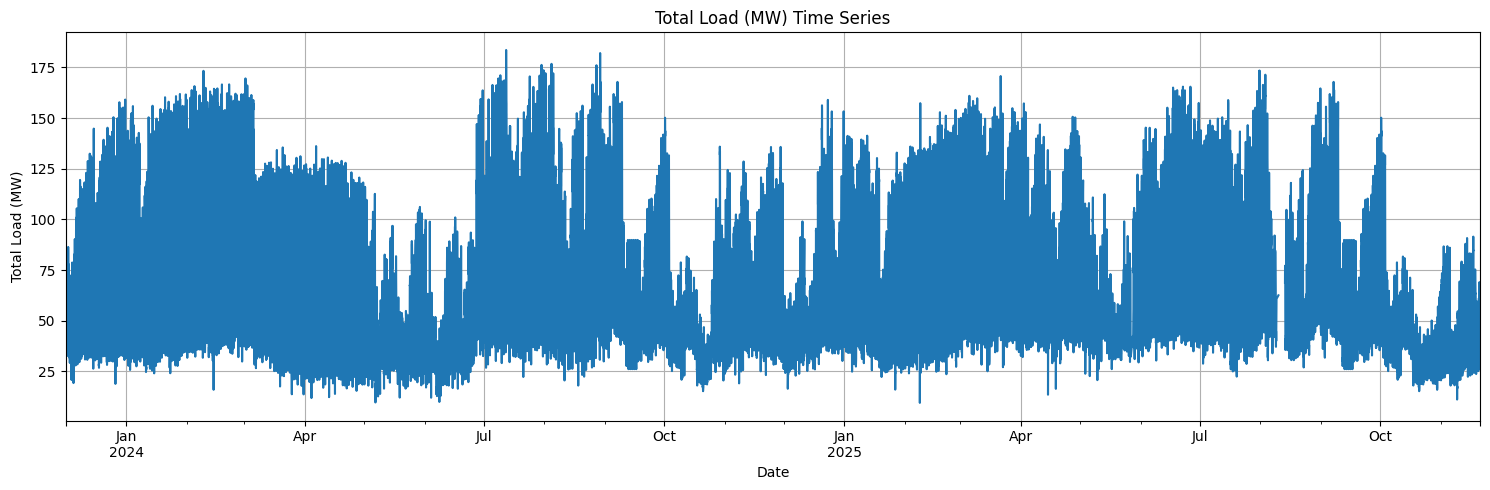

In [7]:
#1. PRE PROCESSING

# we load the dataset and convert it into a useful time series format
data = pd.read_csv('/content/drive/MyDrive/Coding files/Hourly_Data_220kVComma.csv')

data['Datetime'] = pd.to_datetime(
    data['Date'] + ' ' + data['Time'],
    format='%d-%m-%Y %H:%M',
    errors='coerce'
)

data = data.dropna(subset=['Datetime'])

data.set_index('Datetime', inplace=True)

data = data[['Total Load (MW)']]

data = data.sort_index()

print(data.index.min())
print(data.index.max())
print(len(data))

# convert load column to numeric
data['Total Load (MW)'] = pd.to_numeric(
    data['Total Load (MW)'],
    errors='coerce'
)

# Remove duplicate timestamps
data = data[~data.index.duplicated(keep='first')]

# Remove known outage
mask = (
    (data.index >= '2025-08-09 06:00') &
    (data.index <= '2025-08-13 12:00')
)

data = data.loc[~mask]

# Force hourly frequency
data = data.sort_index()
data = data.asfreq('h')

# Find incomplete days
daily_count = data['Total Load (MW)'].resample('D').count()

bad_days = daily_count[daily_count < 24]

print(bad_days)

# Interpolate only small gaps
small_gap_limit = 24

data['Total Load (MW)'] = (
    data['Total Load (MW)']
    .interpolate(
        method='time',
        limit=small_gap_limit
    )
)

#plotting the raw series
plt.figure(figsize=(15, 5))
data['Total Load (MW)'].plot() #automatically use datetime for the x-axis as index
plt.title('Total Load (MW) Time Series')
plt.xlabel('Date')
plt.ylabel('Total Load (MW)')
plt.grid(True)
plt.tight_layout()
plt.show()

In [8]:
# Hour

data['hour'] = data.index.hour

# Day of week

data['dayofweek'] = data.index.dayofweek

# Month

data['month'] = data.index.month

# Weekend

data['is_weekend'] = (
    data.index.dayofweek >= 5
).astype(int)

data['hour_sin'] = np.sin(
    2*np.pi*data['hour']/24
)

data['hour_cos'] = np.cos(
    2*np.pi*data['hour']/24
)

data['dow_sin'] = np.sin(
    2*np.pi*data['dayofweek']/7
)

data['dow_cos'] = np.cos(
    2*np.pi*data['dayofweek']/7
)

features = [
    'Total Load (MW)',
    'hour_sin',
    'hour_cos',
    'dow_sin',
    'dow_cos'
]

data = data[features]

In [9]:
# A row is valid only if every feature is available
valid = data.notna().all(axis=1)

# Assign a new segment number whenever validity changes
segment_id = valid.ne(valid.shift()).cumsum()

segments = []

for _, segment in data.groupby(segment_id):

    # Ignore invalid regions
    if segment.isna().any().any():
        continue

    segments.append(segment)

print(f"Number of continuous segments: {len(segments)}")

for i, seg in enumerate(segments):
    print(f"Segment {i+1}: {seg.index.min()} -> {seg.index.max()} ({len(seg)} rows)")

Number of continuous segments: 2
Segment 1: 2023-12-01 00:00:00 -> 2025-08-10 05:00:00 (14838 rows)
Segment 2: 2025-08-13 13:00:00 -> 2025-11-20 23:00:00 (2387 rows)


In [10]:
train_data = segments[0].copy()
test_data = segments[1].copy()

print("Training period:")
print(train_data.index.min(), "->", train_data.index.max())
print()

print("Testing period:")
print(test_data.index.min(), "->", test_data.index.max())

Training period:
2023-12-01 00:00:00 -> 2025-08-10 05:00:00

Testing period:
2025-08-13 13:00:00 -> 2025-11-20 23:00:00


In [11]:
feature_scaler = MinMaxScaler()
target_scaler = MinMaxScaler()

feature_scaler.fit(train_data)

target_scaler.fit(
    train_data[['Total Load (MW)']]
)

train_scaled = pd.DataFrame(
    feature_scaler.transform(train_data),
    columns=train_data.columns,
    index=train_data.index
)

test_scaled = pd.DataFrame(
    feature_scaler.transform(test_data),
    columns=test_data.columns,
    index=test_data.index
)

In [12]:
INPUT_WINDOW = 168      # Previous 7 days
OUTPUT_WINDOW = 24      # Next 24 hours

target_col = train_scaled.columns.get_loc("Total Load (MW)")


def create_sequences(data):

    values = data.values

    X = []
    y = []

    for i in range(len(values) - INPUT_WINDOW - OUTPUT_WINDOW + 1):

        X.append(
            values[
                i:i+INPUT_WINDOW
            ]
        )

        y.append(
            values[
                i+INPUT_WINDOW:
                i+INPUT_WINDOW+OUTPUT_WINDOW,
                target_col
            ]
        )

    return np.array(X), np.array(y)

In [13]:
X_train, y_train = create_sequences(train_scaled)

X_test, y_test = create_sequences(test_scaled)

print(X_train.shape)
print(y_train.shape)

print(X_test.shape)
print(y_test.shape)

(14647, 168, 5)
(14647, 24)
(2196, 168, 5)
(2196, 24)


In [14]:
LATENT_DIM = 32

encoder_inputs = Input(
    shape=(INPUT_WINDOW, X_train.shape[2])
)

# Encoder
encoder = LSTM(
    LATENT_DIM,
    activation='tanh'
)(encoder_inputs)

encoder = Dropout(0.2)(encoder)

# Repeat context vector
decoder = RepeatVector(
    OUTPUT_WINDOW
)(encoder)

# Decoder
decoder = LSTM(
    LATENT_DIM,
    activation='tanh',
    return_sequences=True
)(decoder)

decoder = Dropout(0.2)(decoder)

decoder = TimeDistributed(
    Dense(32, activation='relu')
)(decoder)

outputs = TimeDistributed(
    Dense(1)
)(decoder)

model = Model(
    encoder_inputs,
    outputs
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 168, 5)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 32)             │         4,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 24, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 24, 32)         │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 24, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 24, 32)         │         1,056 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 24, 1)          │            33 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,273 (55.75 KB)

 Trainable params: 14,273 (55.75 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='mse',
    metrics=['mae']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6
)

In [16]:
history = model.fit(

    X_train,

    y_train.reshape(
        y_train.shape[0],
        OUTPUT_WINDOW,
        1
    ),

    validation_split=0.1,

    epochs=40,

    batch_size=128,

    callbacks=[
        early_stop,
        reduce_lr
    ],

    verbose=1
)

Epoch 1/40
103/103 ━━━━━━━━━━━━━━━━━━━━ 10s 35ms/step - loss: 0.0519 - mae: 0.1881 - val_loss: 0.0437 - val_mae: 0.1743 - learning_rate: 0.0010
Epoch 2/40
103/103 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - loss: 0.0330 - mae: 0.1471 - val_loss: 0.0154 - val_mae: 0.0974 - learning_rate: 0.0010
Epoch 3/40
103/103 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.0206 - mae: 0.1107 - val_loss: 0.0110 - val_mae: 0.0798 - learning_rate: 0.0010
Epoch 4/40
103/103 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0181 - mae: 0.1024 - val_loss: 0.0097 - val_mae: 0.0763 - learning_rate: 0.0010
Epoch 5/40
103/103 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - loss: 0.0169 - mae: 0.0983 - val_loss: 0.0094 - val_mae: 0.0751 - learning_rate: 0.0010
Epoch 6/40
103/103 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.0163 - mae: 0.0956 - val_loss: 0.0106 - val_mae: 0.0795 - learning_rate: 0.0010
Epoch 7/40
103/103 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.0158 - mae: 0.0939 - val_loss: 0.0088 - val_mae: 0.0727 - learning_rate: 0.001

In [17]:
pred = model.predict(X_test)

pred = pred.squeeze(-1)

69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step


In [18]:
pred_actual = target_scaler.inverse_transform(
    pred.reshape(-1,1)
).reshape(pred.shape)

y_actual = target_scaler.inverse_transform(
    y_test.reshape(-1,1)
).reshape(y_test.shape)

In [19]:
mae = mean_absolute_error(
    y_actual.flatten(),
    pred_actual.flatten()
)

rmse = np.sqrt(
    mean_squared_error(
        y_actual.flatten(),
        pred_actual.flatten()
    )
)

r2 = r2_score(
    y_actual.flatten(),
    pred_actual.flatten()
)

print(f"MAE  : {mae:.3f}")
print(f"RMSE : {rmse:.3f}")
print(f"R²   : {r2:.4f}")

MAE  : 10.198
RMSE : 14.252
R²   : 0.8131


In [20]:
# url = (
#     "https://archive-api.open-meteo.com/v1/archive"
#     "?latitude=12.75"
#     "&longitude=78.34"
#     "&start_date=2023-12-01"
#     "&end_date=2025-11-20"
#     "&hourly=temperature_2m,"
#     "relative_humidity_2m,"
#     "precipitation,"
#     "cloud_cover,"
#     "wind_speed_10m"
# )

# wdata = requests.get(url).json()

# weather = pd.DataFrame(wdata["hourly"])

# weather["time"] = pd.to_datetime(weather["time"])

# weather.rename(
#     columns={"time":"Datetime"},
#     inplace=True
# )

# weather.set_index("Datetime", inplace=True)

# weather = weather.sort_index()

# data = data.join(weather, how='left')

NameError: name 'requests' is not defined